In [17]:
import cv2 , numpy as np ,  matplotlib.pyplot as plt , seaborn as sns  

img = cv2.imread('unic.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)  



def show_img_hist(images,title):
    n = len(images)
    fig, ax = plt.subplots(2, n, figsize=(10, 5))

    for i, axx in enumerate(ax[0]):
        axx.imshow(images[i], cmap='gray')   
        axx.set_title(title[i])
        axx.axis("off")  
 
    for i, axx in enumerate(ax[1]):
        axx.hist(images[i].ravel(), bins=256, range=[0, 256])
        axx.set_title(f"Histogram of {title[i]}")
    
    plt.tight_layout()
    plt.show()

# Histogram Shifting

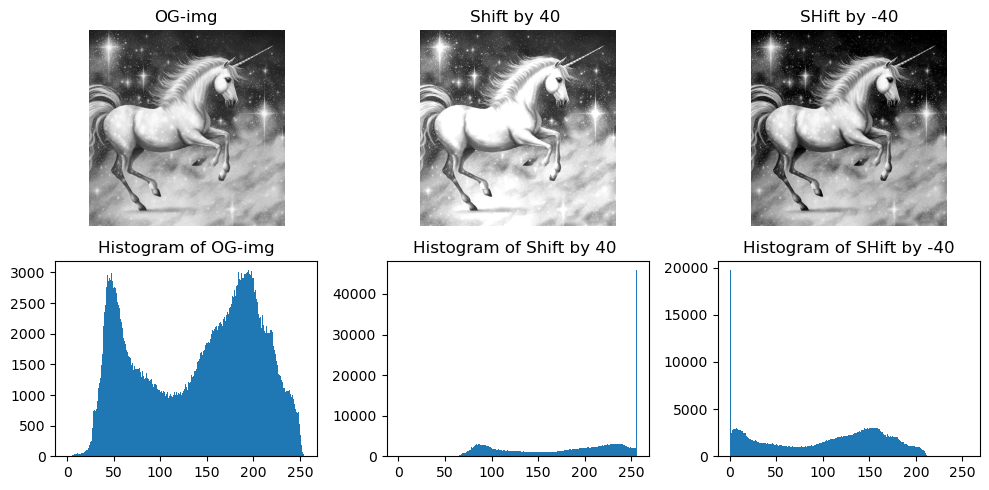

In [20]:
def hist_shift(img ,shift_val):
    
    shift_img = img.copy().astype(np.int16)
    shift_img = np.uint8(np.clip((shift_img+shift_val),0,255))
    return shift_img
    
shift_img_p = hist_shift(img,40)
shift_img_n= hist_shift(img,-40)

show_img_hist([img,shift_img_p,shift_img_n],['OG-img','Shift by 40 ' ,'SHift by -40'])


# Threshold Limiting

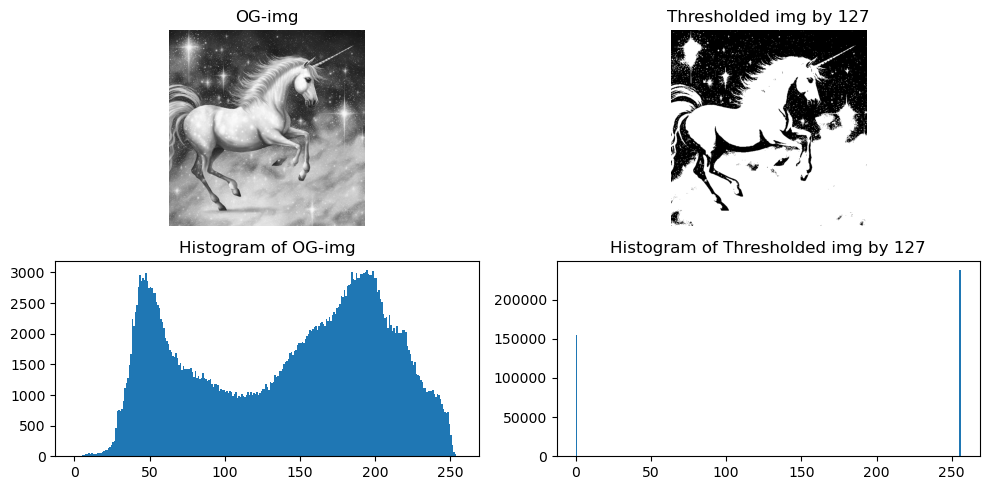

In [22]:
thres_value = 127

new_img = np.zeros_like(img)
new_img[img > thres_value] = 255

show_img_hist([img,new_img],['OG-img','Thresholded img by 127'])


# Negative Image

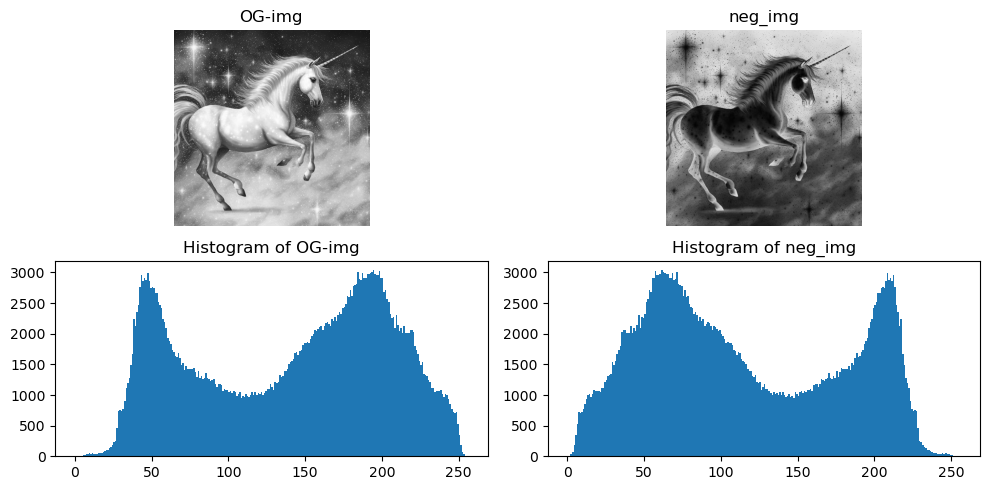

In [24]:
neg_img  =  255 - img
show_img_hist([img,neg_img],['OG-img','neg_img'])


# contrast Stretching

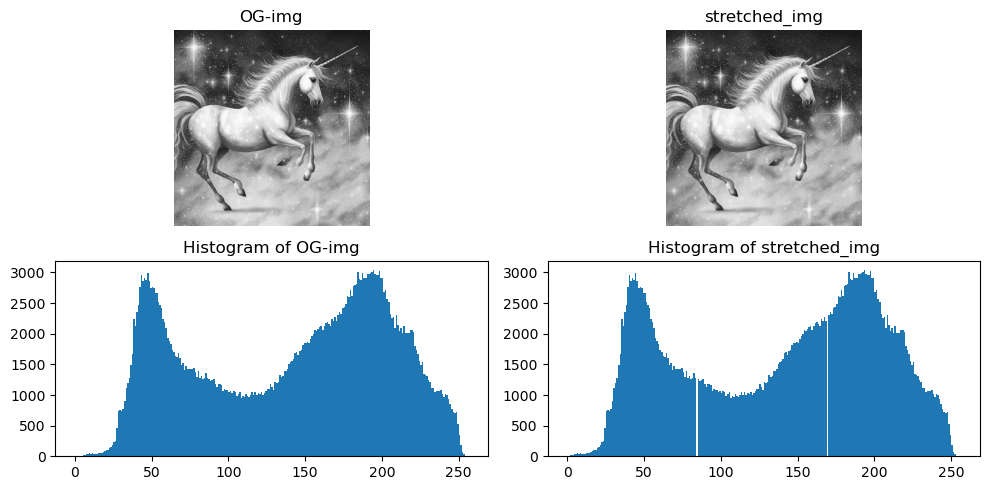

In [26]:
def con_stretching(image):

    
    I_min = np.min(image)
    I_max = np.max(image)
    
    stretched_image = ((image - I_min) / (I_max - I_min)) * 255
    stretched_image = np.clip(stretched_image, 0, 255).astype(np.uint8)
    stretched_image = np.uint8(stretched_image) 
    
    return stretched_image

stretched_img = con_stretching(img)
show_img_hist([img,stretched_img],['OG-img','stretched_img'])


# DFT

Text(0.5, 1.0, 'DFT')

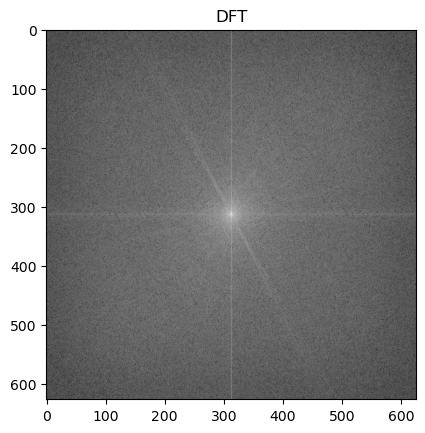

In [338]:
dft = cv2.dft(np.float32(img), flags=cv2.DFT_COMPLEX_OUTPUT)
dft_shift = np.fft.fftshift(dft)
magnitude_spectrum = 20 * np.log(cv2.magnitude(dft_shift[:, :, 0], dft_shift[:, :, 1]))

plt.imshow(magnitude_spectrum,cmap='grey')
plt.title('DFT')

# Smoothening and Shapening

In [19]:
def apply_filter_manual(image, kernel):
    h, w = image.shape
    kh, kw = kernel.shape
    pad = kh // 2  
    padded_image = np.zeros((h + 2 * pad, w + 2 * pad))
    padded_image[pad:h+pad, pad:w+pad] = image  
    filtered_image = np.zeros_like(image, dtype=np.float32)

    for i in range(h):
        for j in range(w):
            region = padded_image[i:i+kh, j:j+kw]  
            filtered_image[i, j] = np.sum(region * kernel)  

    filtered_image = np.clip(filtered_image, 0, 255).astype(np.uint8)
    return filtered_image



In [21]:
imgg = img.copy()

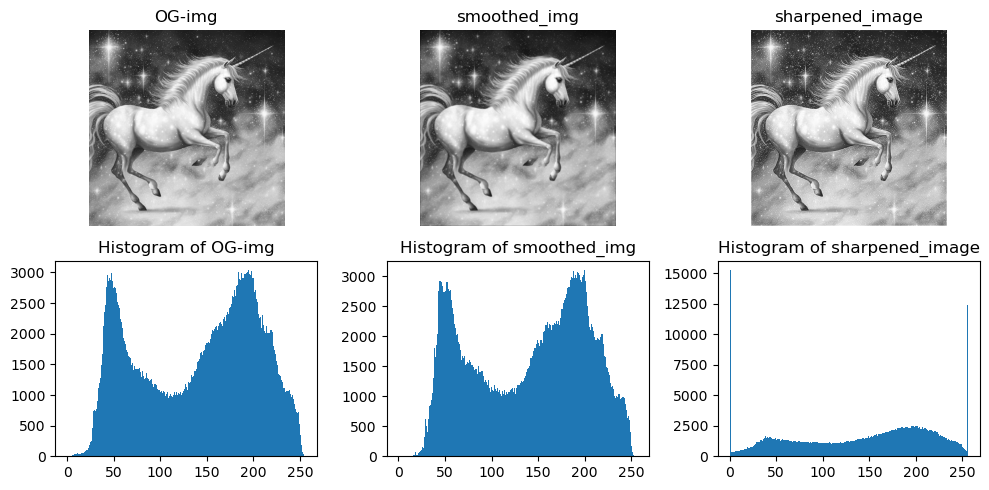

In [23]:
imgg = img.copy()
smoothing_kernel = np.ones((3, 3), dtype=np.float32) / 9  
sharpening_kernel = np.array([[ 0, -1,  0],
                               [-1,  5, -1],
                               [ 0, -1,  0]], dtype=np.float32)

smoothed_img = apply_filter_manual(imgg, smoothing_kernel)
sharpened_img = apply_filter_manual(imgg, sharpening_kernel)

show_img_hist([img,smoothed_img,sharpened_img],['OG-img','smoothed_img','sharpened_image'])
